In [56]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import (
    ResNet34_Weights,
    ResNet50_Weights,
    ResNet101_Weights,
    EfficientNet_B0_Weights,
    MobileNet_V3_Large_Weights,
    MobileNet_V3_Small_Weights
)
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as transforms  # Import the updated torchvision transforms (version 2)
from torchvision import models # To get pre-trained models
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [19]:
def separate_image_files_by_class(image_dir):
    """
    Separates image files in the given directory into two classes based on the first character of the filename.

    Class 0: Filenames starting with a lowercase letter.
    Class 1: Filenames starting with an uppercase letter.

    Parameters:
        image_dir (str): The directory containing image files.

    Returns:
        class0_files (list): List of filenames for class 0. Full paths.
        class1_files (list): List of filenames for class 1. Full paths.
    """

    # List comprehension to gather all image files with specified extensions
    all_image_files = [
        f for f in os.listdir(image_dir)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Initialize lists to store filenames for each class
    class0_files = []  # Class 0 (e.g., dogs, lowercase)
    class1_files = []  # Class 1 (e.g., cats, uppercase)

    # Separate the image files into two classes based on the first character of the filename
    for f in all_image_files:
        if f[0].isupper():
            class1_files.append(os.path.join(image_dir, f))  # Capital letter indicates class 1
        else:
            class0_files.append(os.path.join(image_dir, f))  # Small letter indicates class 0

    return class0_files, class1_files

In [20]:
# both of the dataset classes
class ImageAugmentationDatasetUnbalanced(Dataset):
    """
    A custom PyTorch Dataset class that loads images from a directory,
    applies a series of augmentations to each image, and returns the augmented images and their labels.
    This class is designed to simulate an infinite dataset by wrapping around the dataset indices.
    """

    def __init__(self, image_dir, image_size=(128, 128), is_training=True):
        """
        Initializes the dataset by listing all image files in the specified directory
        and assigning labels based on the filename.

        Args:
            image_dir (str): The directory containing the image files.
            image_size (tuple): The desired output size of the images (width, height).
        """
        self.image_dir = image_dir  # Store the path to the image directory
        self.image_size = image_size  # Store the desired image size
        self.is_training = is_training

        # List comprehension to gather all image files with specified extensions
        self.image_files = [
            f for f in os.listdir(image_dir)
            if f.endswith(('.png', '.jpg', '.jpeg'))
        ]
        # Now, self.image_files contains all the image filenames in the directory

        # Assign labels based on the first character of the filename
        # 1 for "cats" (capital letter), 0 for "dogs" (small letter)
        self.labels = [
            1 if f[0] == 'c' else 0 for f in self.image_files # Changed this here for new testing dataset
        ]

    def __len__(self):
        """
        Returns the total number of images in the dataset.

        Returns:
            int: The number of image files found in the directory.
        """
        return len(self.image_files)  # Return the total count of image files

    def augment(self, image):
        """
        Applies a sequence of augmentation transforms to the input image.

        Args:
            image (PIL.Image.Image): The input image to be augmented.

        Returns:
            torch.Tensor: The augmented image as a tensor.
        """
        # Calculate the minimum size for resizing to ensure the image is large enough after cropping
        min_size = max(self.image_size) + 40  # Add padding (40 pixels) to the largest dimension

        # Normalization (commented out if not needed)
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
        
        # Compose a sequence of augmentation transforms
        aug_transforms = transforms.Compose([
            transforms.Resize((min_size, min_size)),  # Resize the image to at least min_size
            transforms.RandomCrop(size=self.image_size),  # Randomly crop to the desired size
            #transforms.RandomVerticalFlip(),  # Randomly flip the image vertically (Up/Down) with a 50% chance (disabled as we do not expect upsidedown images)
            transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally (Left/Right) with a 50% chance
            transforms.ColorJitter(
                brightness=0.2,  # Adjust brightness by a factor of ±0.5
                contrast=0.2     # Adjust contrast by a factor of ±0.5
            ),
            transforms.RandomAffine(
                degrees=10,              # Rotate the image randomly within ±10 degrees
                scale=(0.7, 1.3),        # Randomly scale the image
                translate=(0.1, 0.1)     # Translate the image randomly by up to 10% in both directions
            ),
            
            transforms.ToImage(),  # Ensure the output is a PIL Image
            transforms.ToDtype(torch.float32, scale=True),  # Convert to float32 tensor and scale pixel values to [0, 1]
            normalize, # Normalize by subtracting mean and dividing by std. deviation (expect negative and positive values)
        ])

        # Transforms for evaluation mode
        out_transforms = transforms.Compose([
            transforms.Resize(self.image_size),  # Resize to the desired size
            transforms.ToImage(),  # Ensure the output is a PIL Image
            transforms.ToDtype(torch.float32, scale=True),  # Convert to float32 tensor and scale pixel values to [0, 1]
            normalize, # Normalize by subtracting mean and dividing by std. deviation (expect negative and positive values)
        ])

        # Apply the composed transforms to the image
        if self.is_training:
            augmented_image = aug_transforms(image)
            return augmented_image  # Return the augmented image tensor
        else:
            output_image = out_transforms(image)
            return output_image  # Return the processed image tensor

    def __getitem__(self, idx):
        """
        Retrieves an augmented image and its label based on the given index.

        Args:
            idx (int): The index of the image to retrieve.

        Returns:
            tuple: A tuple containing the augmented image tensor and its label.
        """
        # Wrap around the dataset indices using modulo to handle infinite indices
        real_idx = idx % len(self.image_files)
        # Construct the full path to the image file
        img_path = os.path.join(self.image_dir, self.image_files[real_idx])
        # Open the image and convert it to RGB mode to ensure consistency
        image = Image.open(img_path).convert('RGB')
        # Apply augmentations to the image
        augmented_image = self.augment(image)
        # Retrieve the label for the current image
        label = self.labels[real_idx]
        return augmented_image, label  # Return the augmented image and its label
class ImageAugmentationDatasetBalanced(Dataset):
    """
    A custom PyTorch Dataset class that loads images from a given lists,
    applies a series of augmentations to each image, and returns the augmented images and their labels.
    This class ensures class balancing between 'cats' and 'dogs' by alternating between classes
    (even indices return one class, odd indices return the other).
    """
    
    def __init__(self, class0_files, class1_files, image_size=(128, 128), is_training=True):
        """
        Initializes the dataset by listing all image files in the specified directory,
        assigning labels based on the filename, and separating the images into two classes.

        Args:
            class0_files (list): List containing the image files for class0.
            class1_files (list): List containing the image files for class1.
            image_size (tuple): The desired output size of the images (width, height).
            is_training (bool): Switch on augmentation of dataset if True.
        """
        
        self.image_size = image_size  # Store the desired image size
        self.is_training = is_training  # Flag indicating training or evaluation mode

        # Initialize lists to store filenames for each class
        self.class0_files = class0_files  # Class 0 (e.g., dogs)
        self.class1_files = class1_files  # Class 1 (e.g., cats)

        # Store the lengths of each class list for later use
        self.len_class0 = len(self.class0_files)
        self.len_class1 = len(self.class1_files)

    def __len__(self):
        """
        If returns a number of max(samples one class, samples other class) * 2

        Returns:
            int: A number representing the dataset length.
        """
        return max(self.len_class0, self.len_class1) * 2

    def augment(self, image):
        """
        Applies a sequence of augmentation transforms to the input image.

        Args:
            image (PIL.Image.Image): The input image to be augmented.

        Returns:
            torch.Tensor: The augmented image as a tensor.
        """
        # Calculate the minimum size for resizing to ensure the image is large enough after cropping
        min_size = max(self.image_size) + 40  # Add padding (40 pixels) to the largest dimension

        # Normalization (commented out if not needed)
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
        
        # Compose a sequence of augmentation transforms
        aug_transforms = transforms.Compose([
            transforms.Resize((min_size, min_size)),  # Resize the image to at least min_size
            transforms.RandomCrop(size=self.image_size),  # Randomly crop to the desired size
            #transforms.RandomVerticalFlip(),  # Randomly flip the image vertically (Up/Down) with a 50% chance (disabled as we do not expect upsidedown images)
            transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally (Left/Right) with a 50% chance
            
            transforms.ColorJitter(
                brightness=0.2,  # Adjust brightness by a factor of ±0.5
                contrast=0.2     # Adjust contrast by a factor of ±0.5
            ),
            transforms.RandomAffine(
                degrees=10,              # Rotate the image randomly within ±10 degrees
                scale=(0.7, 1.3),        # Randomly scale the image
                translate=(0.1, 0.1)     # Translate the image randomly by up to 10% in both directions
            ),
            
            transforms.ToImage(),  # Ensure the output is a PIL Image
            transforms.ToDtype(torch.float32, scale=True),  # Convert to float32 tensor and scale pixel values to [0, 1]
            normalize, # Normalize by subtracting mean and dividing by std. deviation (expect negative and positive values)
        ])

        # Transforms for evaluation mode
        out_transforms = transforms.Compose([
            transforms.Resize(self.image_size),  # Resize to the desired size
            transforms.ToImage(),  # Ensure the output is a PIL Image
            transforms.ToDtype(torch.float32, scale=True),  # Convert to float32 tensor and scale pixel values to [0, 1]
            normalize, # Normalize by subtracting mean and dividing by std. deviation (expect negative and positive values)
        ])

        # Apply the composed transforms to the image
        if self.is_training:
            augmented_image = aug_transforms(image)
            return augmented_image  # Return the augmented image tensor
        else:
            output_image = out_transforms(image)
            return output_image  # Return the processed image tensor

    def __getitem__(self, idx):
        """
        Retrieves an augmented image and its label based on the given index,
        ensuring class balancing by alternating between classes.

        Args:
            idx (int): The index of the image to retrieve.

        Returns:
            tuple: A tuple containing the augmented image tensor and its label.
        """
        # Determine which class to sample from based on the index parity
        if idx % 2 == 0:
            # Even index: sample from class 0 (e.g., dogs)
            class_files = self.class0_files
            label = 0
            class_len = self.len_class0
        else:
            # Odd index: sample from class 1 (e.g., cats)
            class_files = self.class1_files
            label = 1
            class_len = self.len_class1

        # Compute the index within the class list, wrapping around if necessary
        class_idx = (idx // 2) % class_len

        # Get the filename of the image
        filename = class_files[class_idx]

        # Construct the full path to the image file
        #img_path = os.path.join(self.image_dir, filename)

        # Open the image and convert it to RGB mode to ensure consistency
        image = Image.open(filename).convert('RGB')

        # Apply augmentations to the image
        augmented_image = self.augment(image)

        # print(torch.min(augmented_image).item())
        # print(torch.max(augmented_image).item())
        
        return augmented_image, label  # Return the augmented image and its label


In [21]:
# Hyper parameters
batch_size = 64
num_epochs = 25
image_size=(128, 128)

In [22]:
# building the dataset from the lecture notes
dog, cat = separate_image_files_by_class("images") # cat dog seperation

validation_len = int(min(len(dog), len(cat)) * 0.2) # 80 20 split

# Randomly sample validation_len files from each class
val_dog = random.sample(dog, validation_len)
val_cat = random.sample(cat, validation_len)

training_class0_files = list(set(dog) - set(val_dog))
training_class1_files = list(set(cat) - set(val_cat))

train_dataset = ImageAugmentationDatasetBalanced(training_class0_files, training_class1_files, image_size=image_size, is_training=True)
validation_dataset = ImageAugmentationDatasetBalanced(val_dog, val_cat, image_size=image_size, is_training=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [23]:
test_dataset = ImageAugmentationDatasetUnbalanced("test", image_size=image_size, is_training=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [27]:
# Training loop function. Same loop but I just wrapped it to a function for different models
def train_model(model, train_loader, validation_loader, device, num_epochs=10, lr=1e-4, gamma=0.98, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        train_loader_tqdm = tqdm(train_loader, desc=f"{model_name.upper()} Epoch {epoch+1}/{num_epochs} [Training]", leave=False, ascii=True)
        
        for images, labels in train_loader_tqdm:
            # Training part
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            train_loader_tqdm.set_postfix({'Loss': f'{loss.item():8.4f}'})
            
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        print(f'{model_name.upper()} | Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f}, Acc: {epoch_accuracy:.2f}%')
            
            # Validation part
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        validation_loader_tqdm = tqdm(validation_loader, desc=f"{model_name.upper()} Epoch {epoch+1}/{num_epochs} [Validation]", leave=False, ascii=True)
            
        with torch.no_grad():
            for images, labels in validation_loader_tqdm:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                validation_loader_tqdm.set_postfix({'Loss': f'{loss.item():8.4f}'})

        val_epoch_loss = val_loss / len(validation_loader)
        val_accuracy = 100 * correct / total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_accuracy)
            
        print(f'{model_name.upper()} | Val Loss: {val_epoch_loss:.4f}, Acc: {val_accuracy:.2f}%')
            
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f'{model_name}: Best model saved (val_loss={best_val_loss:.4f})')

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        print(f'Learning rate adjusted to: {current_lr:.7f}')
        
    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
def get_model(model_name, num_classes=2):
    if model_name == "resnet34": # all these are just model initilizers
        base = models.resnet34(weights=ResNet34_Weights.DEFAULT) # model_weights.default means that the best available weights for the pretrained model
    elif model_name == "resnet50":
        base = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    elif model_name == "resnet101":
        base = models.resnet101(weights=ResNet101_Weights.DEFAULT)
    elif model_name == "efficientnet_b0":
        base = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    elif model_name == "mobilenet_v3_large":
        base = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
    elif model_name == "mobilenet_v3_small":
        base = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

    # changeing the last classifier head to match with cat and dog classes
    if hasattr(base, 'fc'):  # this part is only for resnet, getting the number of heads it has, and turning it into 2 out put linear layer for my classes
        num_ftrs = base.fc.in_features
        base.fc = nn.Linear(num_ftrs, num_classes)
    elif hasattr(base, 'classifier'):  # for efficientnet and mobilenets, pretty much the same as resnet but only the name is different and the classifiers are at the end of the sequence
        if isinstance(base.classifier, nn.Sequential):
            num_ftrs = base.classifier[-1].in_features
            base.classifier[-1] = nn.Linear(num_ftrs, num_classes)
        else:
            num_ftrs = base.classifier.in_features
            base.classifier = nn.Linear(num_ftrs, num_classes)

    return base

In [ ]:
def get_model(model_name, num_classes=2):
    if model_name == "resnet34":
        base = models.resnet34(weights=ResNet34_Weights.DEFAULT)
    elif model_name == "resnet50":
        base = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    elif model_name == "resnet101":
        base = models.resnet101(weights=ResNet101_Weights.DEFAULT)
    elif model_name == "efficientnet_b0":
        base = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    elif model_name == "mobilenet_v3_large":
        base = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
    elif model_name == "mobilenet_v3_small":
        base = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    if hasattr(base, 'fc'):
        num_ftrs = base.fc.in_features
        base.fc = nn.Linear(num_ftrs, num_classes)
    elif hasattr(base, 'classifier'):  
        if isinstance(base.classifier, nn.Sequential):
            num_ftrs = base.classifier[-1].in_features
            base.classifier[-1] = nn.Linear(num_ftrs, num_classes)
        else:
            num_ftrs = base.classifier.in_features
            base.classifier = nn.Linear(num_ftrs, num_classes)
    return base

In [37]:
# Train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_names = [
    "resnet34",
    "resnet50",
    "resnet101",
    "efficientnet_b0",
    "mobilenet_v3_large",
    "mobilenet_v3_small"
]
results = {}

for name in model_names:
    print(f"\nTraining {name.upper()} ...")
    model = get_model(name).to(device)
    train_losses, val_losses, train_acc, val_acc = train_model(model, train_loader, validation_loader, device, num_epochs=15, model_name=name)
    results[name] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_acc,
        'val_acc': val_acc
    }

MOBILENET_V3_SMALL | Epoch 8/15 | Train Loss: 0.0769, Acc: 96.98%


MOBILENET_V3_SMALL | Val Loss: 0.1485, Acc: 94.48%
Learning rate adjusted to: 0.0000851


MOBILENET_V3_SMALL | Epoch 9/15 | Train Loss: 0.0765, Acc: 97.03%


MOBILENET_V3_SMALL | Val Loss: 0.1316, Acc: 95.52%
mobilenet_v3_small: Best model saved (val_loss=0.1316)
Learning rate adjusted to: 0.0000834


MOBILENET_V3_SMALL | Epoch 10/15 | Train Loss: 0.0717, Acc: 97.27%


...

MOBILENET_V3_SMALL | Val Loss: 0.1654, Acc: 94.58%
Learning rate adjusted to: 0.0000769


MOBILENET_V3_SMALL | Epoch 14/15 | Train Loss: 0.0512, Acc: 98.08%


MOBILENET_V3_SMALL | Val Loss: 0.1572, Acc: 95.00%
Learning rate adjusted to: 0.0000754


MOBILENET_V3_SMALL | Epoch 15/15 | Train Loss: 0.0534, Acc: 98.00%


MOBILENET_V3_SMALL | Val Loss: 0.1818, Acc: 94.90%
Learning rate adjusted to: 0.0000739


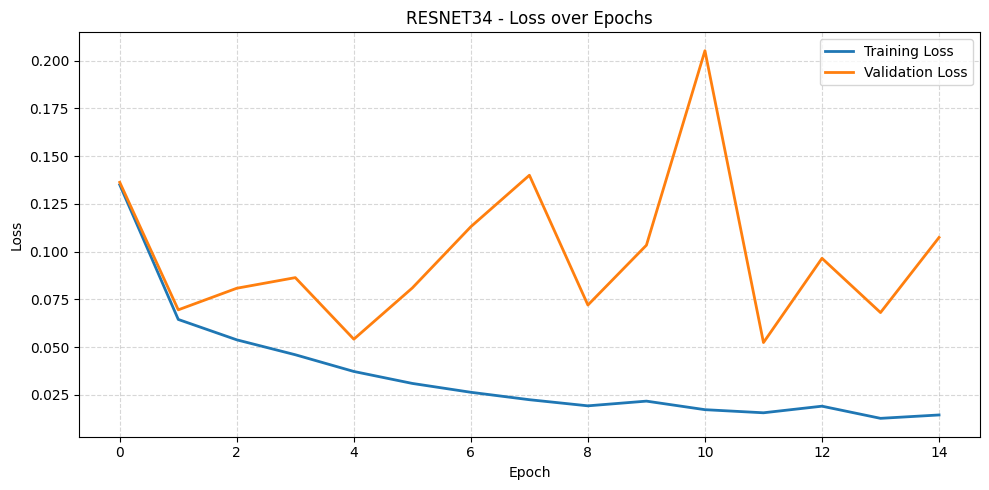

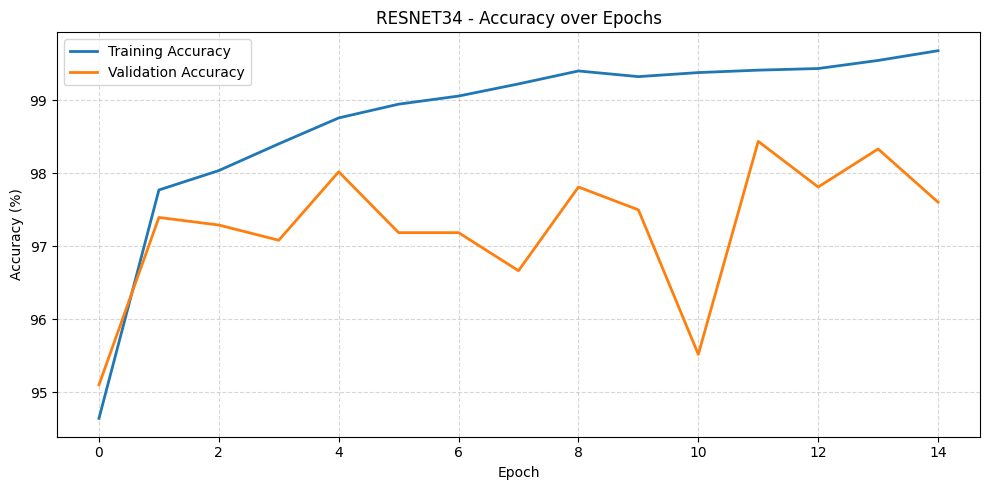

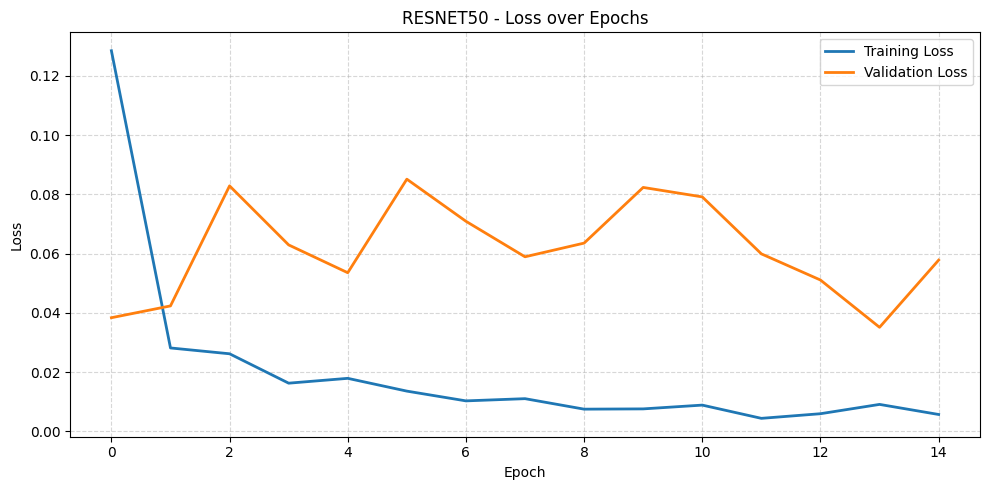

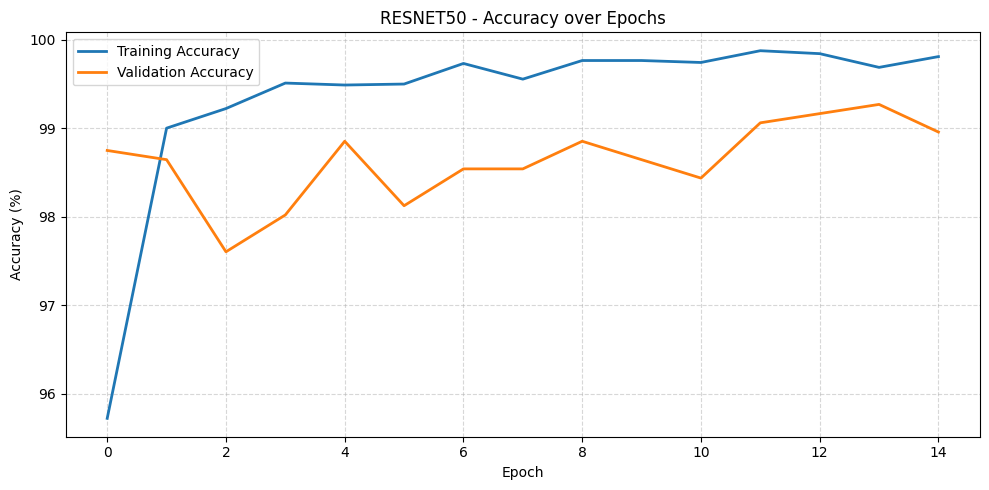

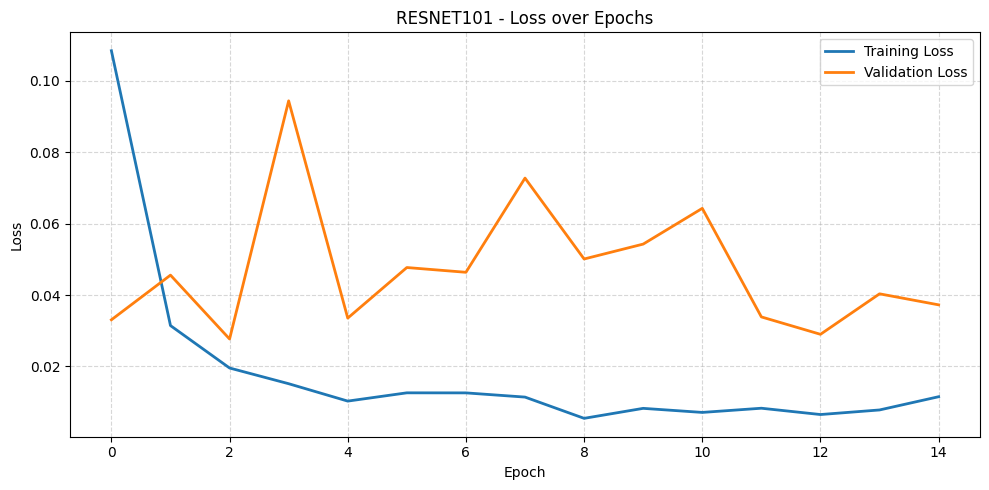

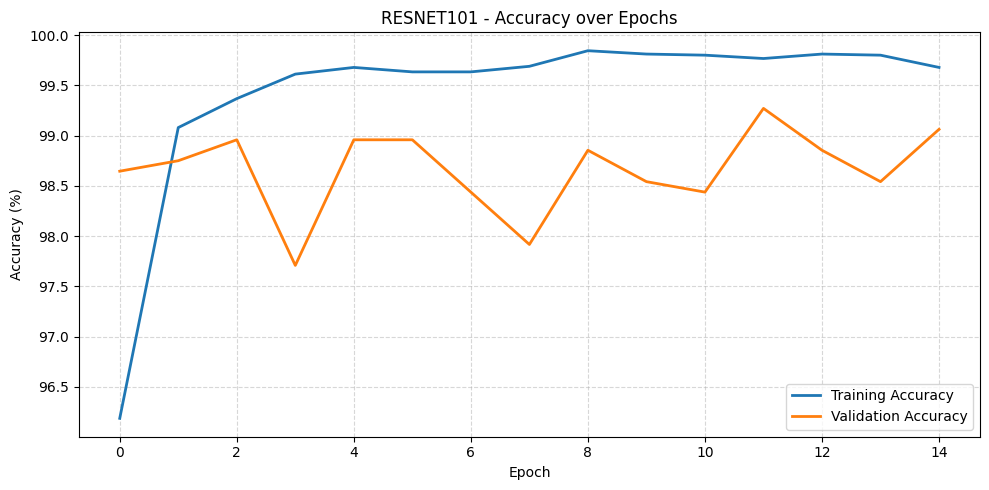

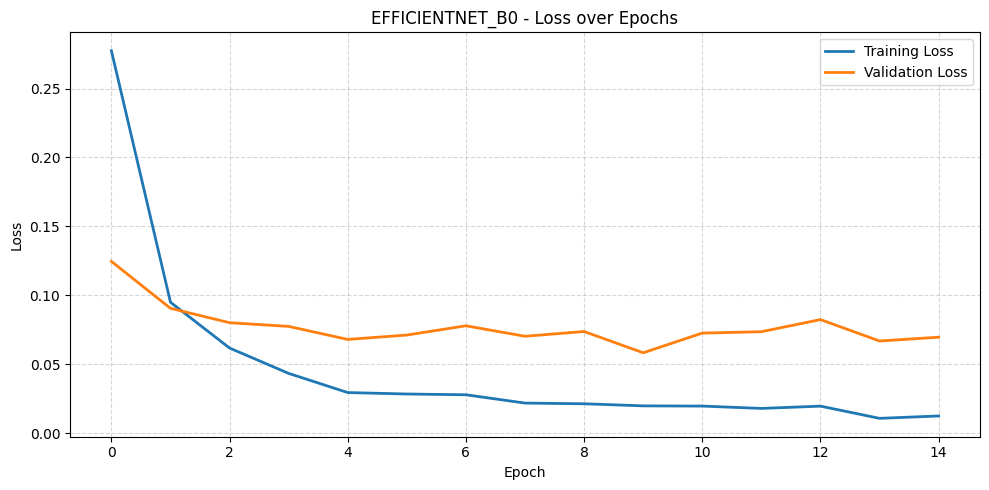

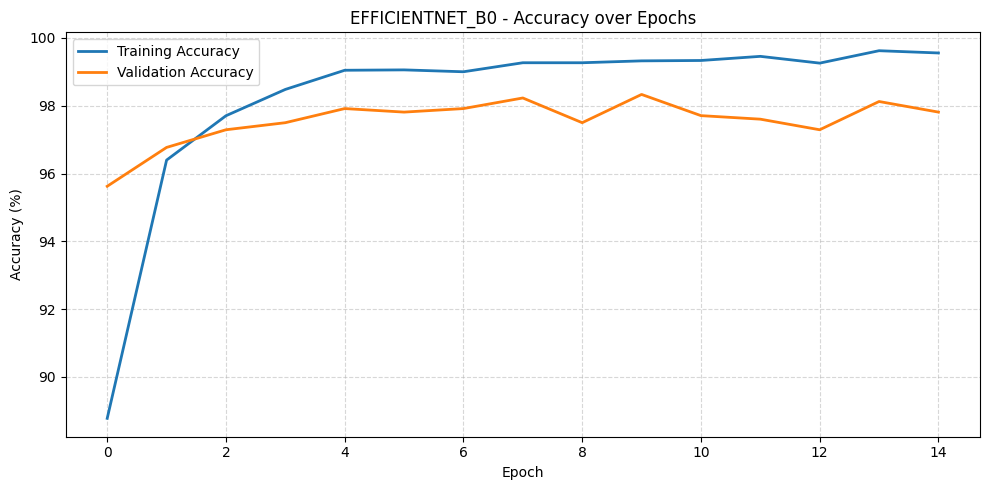

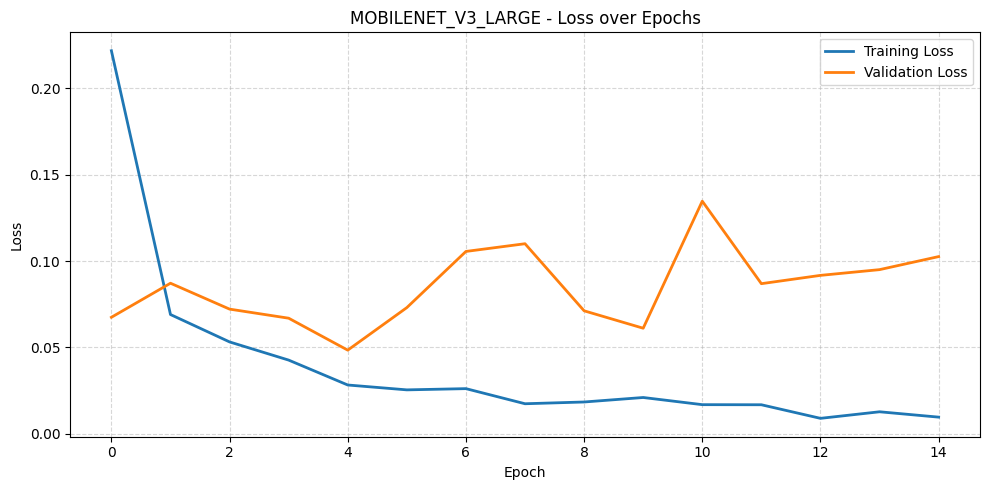

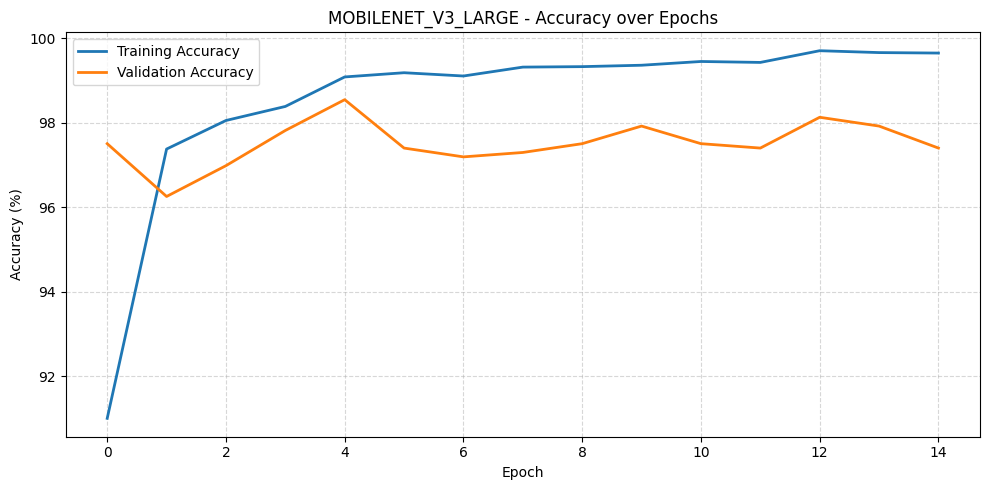

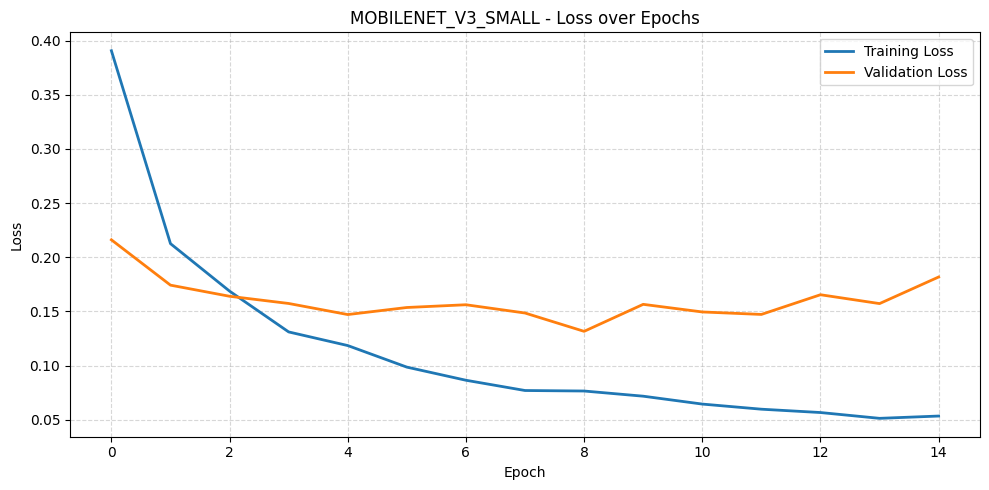

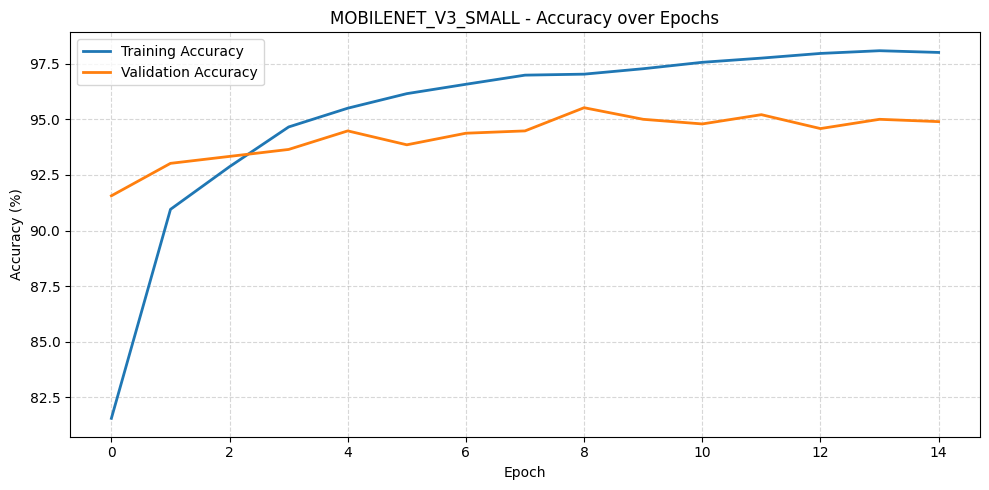

In [38]:
for model_name, metrics in results.items():
    train_losses = metrics['train_loss']
    val_losses = metrics['val_loss']
    train_accuracies = metrics['train_acc']
    val_accuracies = metrics['val_acc']

    # --- Plot Losses ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.title(f'{model_name.upper()} - Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Plot Accuracies ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Training Accuracy', linewidth=2)
    plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
    plt.title(f'{model_name.upper()} - Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

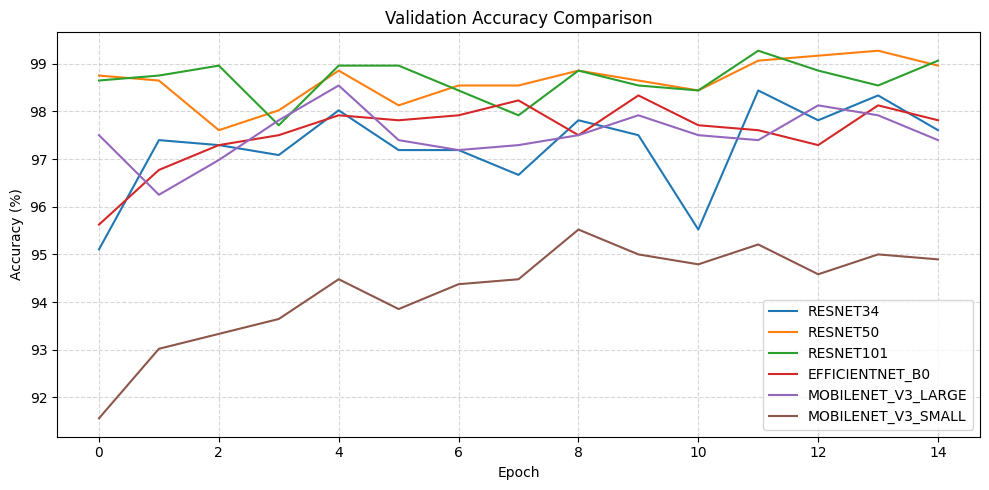

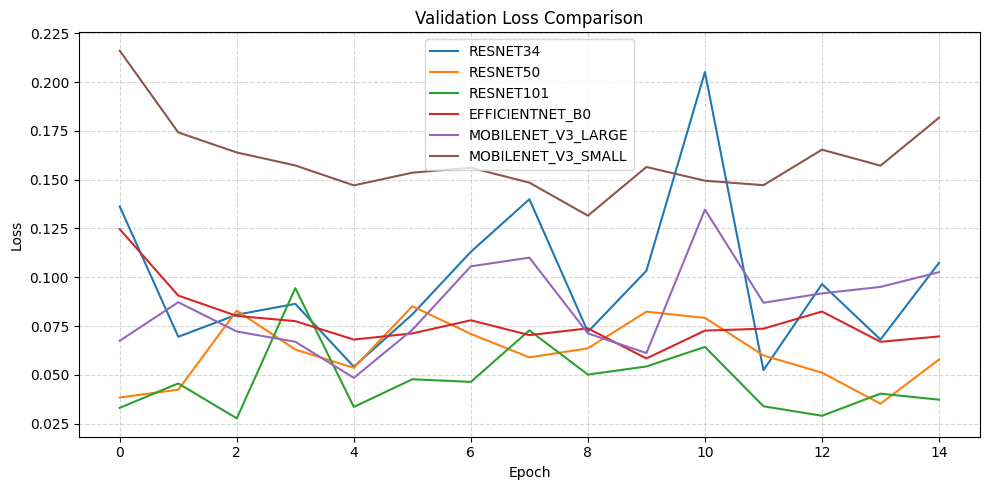

In [ ]:
plt.figure(figsize=(10, 5))
for name, metrics in results.items():
    plt.plot(metrics['val_acc'], label=f'{name.upper()}')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
for name, metrics in results.items():
    plt.plot(metrics['val_loss'], label=f'{name.upper()}')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Testing functions
def evaluate_model(model, dataloader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            preds.extend(predictions.cpu().numpy())
            labels.extend(targets.cpu().numpy())
    
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='binary')
    rec = recall_score(labels, preds, average='binary')
    f1 = f1_score(labels, preds, average='binary')
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": confusion_matrix(labels, preds),
        "report": classification_report(labels, preds, target_names=["Cat", "Dog"])
    }


In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_results = {}
model_paths = ["best_efficientnet_b0.pth",
               "best_mobilenet_v3_large.pth",
               "best_mobilenet_v3_small.pth",
               "best_resnet101.pth",
               "best_resnet34.pth",
               "best_resnet50.pth"]

for path in model_paths:
    model_name = path.replace("best_", "").replace(".pth", "")
    print(f"\nEvaluating {model_name}")
    model = get_model(model_name).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    metrics = evaluate_model(model, test_loader, device)
    test_results[model_name] = metrics

# ===== Summary =====
print("\nTest Results Summary:")
for model_name, metrics in test_results.items():
    print(f"\nModel: {model_name}")
    print(f"Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"Precision: {metrics['precision']*100:.2f}%")
    print(f"Recall:    {metrics['recall']*100:.2f}%")
    print(f"F1-score:  {metrics['f1']*100:.2f}%")
    print(f"Confusion Matrix:\n{metrics['confusion_matrix']}")


Evaluating efficientnet_b0

Evaluating mobilenet_v3_large

Evaluating mobilenet_v3_small

Evaluating resnet101

Evaluating resnet34

Evaluating resnet50

Test Results Summary:

Model: efficientnet_b0
Accuracy:  93.40%
Precision: 96.90%
Recall:    89.68%
F1-score:  93.15%
Confusion Matrix:
[[338  10]
 [ 36 313]]

Model: mobilenet_v3_large
Accuracy:  92.97%
Precision: 95.45%
Recall:    90.26%
F1-score:  92.78%
Confusion Matrix:
[[333  15]
 [ 34 315]]

Model: mobilenet_v3_small
Accuracy:  87.80%
Precision: 91.25%
Recall:    83.67%
F1-score:  87.29%
Confusion Matrix:
[[320  28]
 [ 57 292]]

Model: resnet101
Accuracy:  94.98%
Precision: 93.85%
Recall:    96.28%
F1-score:  95.05%
Confusion Matrix:
[[326  22]
 [ 13 336]]

Model: resnet34
Accuracy:  91.54%
Precision: 94.75%
Recall:    87.97%
F1-score:  91.23%
Confusion Matrix:
[[331  17]
 [ 42 307]]

Model: resnet50
Accuracy:  95.70%
Precision: 98.78%
Recall:    92.55%
F1-score:  95.56%
Confusion Matrix:
[[344   4]
 [ 26 323]]
